# **Algoritmos de optimización - Seminario**<br>

**Nombre y Apellidos:** Celia Pérez Alonso y Paula Caro Miralles   <br>
**Url:** https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---2019/tree/master/SEMINARIO<br>
**URL Google Colab:** https://colab.research.google.com/drive/1PSBvBJPFQim_sFFs93J4XMSuAVOcs1L3?usp=sharing

**Problema:**
1.   **Sesiones de doblaje**
2.   Organizar los horarios de partidos de La Liga
3.   Combinar cifras y operaciones



**Descripción del problema:**

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las
tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de
doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de
grabación independientemente del número de tomas que se graben. No es posible grabar más
de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los
servicios de los actores de doblaje sea el menor posible.

**Datos**:

*   Número de Actores: 10
*   Número de Tomas: 30
*   Actores/Tomas: https://bit.ly/36D8IuK
      *   1 indica que el actor participa en la toma.
      *   0 indica que el actor no participa en la toma

(*) La respuesta es obligatoria





                                        

(*) **¿Cuantas posibilidades hay sin tener en cuenta las restricciones?**



**¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones?**




- ***Posibilidades sin tener en cuenta restricciones:***

Al no tener en cuenta las restricciones, en particular la que nos restringe el número máximo de tomas grabadas cada día, tenemos que cada toma se puede asignar a cualquiera de los $D$ días de forma independiente. Fijamos $ D =$ número de tomas, ya que dejar días de descanso entre grabaciones de tomas, no influye en el número total de días usado para realizar las grabaciones. Además, no tendremos en cuenta el orden de grabación, ya que, por ejemplo, el día 1 y el día 2 son distinguibles en el problema y no va a afectar el coste final.

Por lo tanto,

$$posibilidades\_totales = D^T = 30^{30}$$


- ***Posibilidades teniendo en cuenta todas las restricciones:***

Ahora, teniendo en cuenta que como máximo cada día podemos grabar 6 tomas, el problema se reduce a de cuántas formas podemos agrupar 30 tomas en grupos de tamaño máximo 6.

Entonces, hay que sumar sobre todas las formas posibles de partir 30 tomas en grupos de tamaño $\leq 6$:
$$posibilidades\_totales = \sum_{k_1 + k_2 + \dots + k_d = 30 \\ 1 \leq k_i \leq 6} \frac{30!}{k_1!\cdot k_2! \dots k_d!}$$

Sin embargo, podríamos rebajarlo a un caso más restrictivo. Como estamos intentando minimizar los gastos, trataremos de maximizar el número de tomas por día, esto es, cada día grabaremos 6 tomas. Por lo tanto, el número de días (D) serían 5 y quedaría:
$$
posibilidades\_totales = \frac{T!}{(6!)^D} = \frac{30!}{6!\cdot6!\cdot6!\cdot6!\cdot6!} = \frac{30!}{(6!)^5}
$$

## Modelo para el espacio de soluciones<br>
(*) **¿Cual es la estructura de datos que mejor se adapta al problema? Arguméntalo.** (Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguméntalo)


Bajo nuestro punto de vista, la estructura de datos que mejor se adapta el problema es la lista. Esta lista tendrá la misma longitud que el número de tomas; es decir, 30. Y el valor en la posición $i$ indicará el día en que se ha de grabar la toma $i$. Esto es,

$$sol = [t_1, t_2, \dots, t_{30}]$$

Dónde,

*   $t_i \in {1, 2, \dots, 30}$
*   La toma $i$ se grabará el dia $t_i$.



## Según el modelo para el espacio de soluciones<br>
(*) **¿Cual es la función objetivo?**

(*) **¿Es un problema de maximización o minimización?**

Definimos los **parámetros**:

- $X_{t, a}$ : 1 si en la toma "$t$" participa el actor "$a$", 0 si no (matriz de datos)
- $D= 30$ días
- $T=30$ tomas
- $A = 10$ actores

Definimos también las **variables**:
$$
y_{a, d} =
\begin{cases}
  1, & \text{ si el actor "a" va el día "d" } \\
  0, & \text{ en caso contrario }
\end{cases}\\
z_{t, d} =
\begin{cases}
  1, & \text{ si se graba la toma "t" el día "d" } \\
  0, & \text{ en caso contrario }
\end{cases}
$$

Así, las **restricciones** quedan:
*   `R1`: Todas las tomas han de grabarse exactamente una vez: $\sum_{d = 1}^D z_{t, d} = 1, \quad \forall t \in {1, \dots, T}$
*   `R2`: Como máximo podemos grabar 6 tomas por día: $\sum_{t = 1}^T z_{t, d} \leq 6, \quad \forall d \in {1, \dots, D}$
*   `R3`: Todos los actores implicados en una toma deben estar presente cuando se está grabando: $y_{a, d} \geq x_{a,t}\cdot z_{t,d}, \forall t, d, a$
    * La *lógica* para esta expresión es la siguiente: si planeamos la toma $t$ el día "d" ($z_{t,d} = 1$), y el actor $a$ participa en esta toma ($x_{t,a}=1$), entonces necesitamos que el actor acuda ese día ($y_{a,d} = 1$).

Finalmente, la **función objetivo** es:
$$\min \sum_{a=1}^A \sum_{d=1}^D c_{a, d}\cdot y_{a, d}$$

Dónde $c_{a,d} = \text{"coste del actor a el día d"}$. Como por el enunciado sabemos que estos costes son fijos para todos los actores y días, la función objetivo se simplifica de la siguiente manera:
$$\min \sum_{a=1}^A \sum_{d=1}^D  y_{a, d}$$

Resultando así un problema de minimización.


# Diseña un algoritmo para resolver el problema por fuerza bruta

Primero vamos a ejecutar unas celdas comunes a los algoritmos (imports, lectura de fichero y visualización de la solución):

In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import csv
import math
import itertools
from collections import Counter
import time
import random
import signal
from google.colab import files

# Asignacion de Costes
################################################################################
#      A C T O R
#   T
#   O
#   M
#   A

uploaded = files.upload()  # Abrimos un diálogo para subir el archivo
matriz_tomas = []

with open('datos_problema1.csv', 'r', encoding='utf-8') as archivo:
    lector = csv.reader(archivo, delimiter=';')
    filas = list(lector)

    # 1. Saltamos las 2 primeras filas (índices 0 y 1) qllue son cabeceras
    # 2. Leemos solo hasta la fila 31 (índice 31), ignorando los "TOTALES" del final
    for fila in filas[2:32]:
        # 3. Nos quedamos solo con las columnas de la 1 a la 10 (los actores)
        # y convertimos los valores de texto a enteros (0 o 1)
        actores_en_toma = [int(x) for x in fila[1:11]]
        matriz_tomas.append(actores_en_toma)
matriz_tomas = np.array(matriz_tomas)

# Comprobación de la Toma 1
print(f"Total de tomas cargadas: {len(matriz_tomas)}")
print(f"Toma 1: {matriz_tomas[0]}")

def mostrar_solucion(sol, matriz_tomas):
  sol = np.array(sol)
  matriz_tomas = np.array(matriz_tomas)

  max_dias = sol.max()
  coste_total = 0

  print("="*60)
  print( "       PLANIFICACIÓN DEL RODAJE")
  print("="*60)

  for dia in range(1, max_dias+1):
    indices_tomas = np.where(sol == dia)[0]

    # Actores implicados ese dia
    actores_dia = np.sum(matriz_tomas[indices_tomas], axis = 0)
    actores_implicados = [f"Actor {a+1}" for a in range(len(actores_dia)) if actores_dia[a] > 0]
    coste_dia = len(actores_implicados)
    coste_total += coste_dia

    tomas = ", ".join([f"Toma {t+1}" for t in indices_tomas])
    actores = ", ".join(actores_implicados)

    print(f"\n DÍA {dia}")
    print(f"    Tomas     : {tomas}")
    print(f"    Actores   : {actores}")
    print(f"    Coste día : {coste_dia} actor(es)")
    print("-" * 60)

    print(f"\n COSTE TOTAL: {coste_total} actor(es)-día\n")
    print("=" * 60)

Saving datos_problema1.csv to datos_problema1.csv
Total de tomas cargadas: 30
Toma 1: [1 1 1 1 1 0 0 0 0 0]


Como intuimos que la fuerza bruta va a resultar inviable debido al tamaño de los datos, vamos a reducir el espacio de búsqueda con $D =\lceil 30/6 \rceil = 5$ días.

In [2]:
def coste(sol, matriz_tomas):
    T = matriz_tomas.shape[0]
    D = math.ceil(T/6)
    A = matriz_tomas.shape[1]

    sol_np = np.array(sol)
    matriz_tomas = np.array(matriz_tomas)

    coste_total = 0
    for dia in range(1, D+1):
        indices = np.where(sol_np == dia)[0]

        if len(indices) == 0:
            continue # Si no hay tomas este día, pasamos al siguiente

        # Sumamos todas las columnas de una sola vez (axis=0)
        actores_dia = np.sum(matriz_tomas[indices], axis=0)

        # Contamos cuántos actores tienen 0 (no trabajan)
        ceros = np.count_nonzero(actores_dia == 0)
        coste_total += (A - ceros)
        # print(coste_total)

    return coste_total

def fuerza_bruta(matriz_tomas):
    T = matriz_tomas.shape[0]
    D = math.ceil(T/6)
    A = matriz_tomas.shape[1]

    mejor_coste = float('inf')
    mejor_sol = None

    # Todas las formas de asignar T tomas a D días
    for sol in itertools.product(range(1, D+1), repeat=T):
        # print(f"Probando solucion: {sol}")
        # Verificar que cada día tiene exactamente 6 tomas
        conteo = Counter(sol)
        if any(conteo[d] > 6 for d in range(1, D+1)):
            continue
        c = coste(sol, matriz_tomas)
        # print(f"Coste de dicha solución: {c}.")

        if c < mejor_coste:
            mejor_coste = c
            mejor_sol = list(sol)

    return mejor_sol, mejor_coste

In [ ]:
# Probamos el algoritmo de fuerza bruta para un número menor de tomas (ya que para grandes datos se vuelve inviable)
solucion, coste = fuerza_bruta(matriz_tomas[:13])

mostrar_solucion(solucion, matriz_tomas[:13])

       PLANIFICACIÓN DEL RODAJE

 DÍA 1
    Tomas     : Toma 1, Toma 2, Toma 3, Toma 4, Toma 5, Toma 11
    Actores   : Actor 1, Actor 2, Actor 3, Actor 4, Actor 5, Actor 7, Actor 8
    Coste día : 7 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 7 actor(es)-día


 DÍA 2
    Tomas     : Toma 6, Toma 7, Toma 8, Toma 9, Toma 10, Toma 12
    Actores   : Actor 1, Actor 2, Actor 3, Actor 4, Actor 5, Actor 6, Actor 9
    Coste día : 7 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 14 actor(es)-día


 DÍA 3
    Tomas     : Toma 13
    Actores   : Actor 1, Actor 4, Actor 5
    Coste día : 3 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 17 actor(es)-día



**Calcula la complejidad del algoritmo por fuerza bruta**

Calculamos por partes:

1. `coste(sol, matriz_tomas)`

* `np.where(sol_np == dia)` → recorre T elementos = T ops
* `np.sum(matriz_tomas[indices], axis=0)` → suma a lo sumo T filas de A columnas = T×A ops
* `np.count_nonzero(actores_dia == 0)` → A ops
* `coste_total += (A - ceros)` → 2 ops
* Todo esto dentro del bucle de D días, por lo tanto:
$$
coste=D⋅(T+T⋅A+A + 2)=D⋅(T(A+1)+A+2 )
$$

Con $D=5, T=30, A=10$:
$$
5⋅(30⋅11+10 + 2)=5⋅342=1710\text{ ops}
$$

Como el término dominante es $D\cdot T\cdot A$:

$$\boxed{O(D\cdot T\cdot A)}$$


2. `fuerza_bruta`

* `Counter(sol)` → T ops
* `any(conteo[d] > 6 ...)` → D ops
* `coste(sol, matriz_tomas)` → D·T·A ops
* Todo esto dentro del bucle `itertools.product(range(1, D+1), repeat=T)`, que suma un total de $D^T$ combinaciones.

Por lo tanto,
$$
\text{fuerza bruta} = D^T \cdot (T + D + D \cdot T \cdot A)
$$

Como el término dominante es $D^T \cdot D \cdot T \cdot A$:

$$\boxed{O(D^T \cdot D \cdot T \cdot A)}$$

Con $D=5, T=30, A=10$:
$$
5^{30}\cdot5\cdot30\cdot10\approx9.3\cdot10^{20}\cdot1500\approx10^{24}\text{ops}
$$

(*) **Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta**

Nuestro primer enfoque para mejorar el algoritmo de fuerza bruta fue implementar backtracking, ya que esta técnica permite evitar la exploración completa del espacio de búsqueda. Si en una rama parcial se detecta que se incumple alguna restricción, como sería en el caso de nuestro problema superar las 6 tomas por día, esa rama se descarta y deja de expandirse.

Después de varios intentos, se observó que el método de backtracking puro seguía presentando problemas de rendimiento para instancias de mayor tamaño. Por esto, se decidió añadir una poda por coste parcial (Branch and Bound) que va calculando el coste de soluciones parciales, lo que permite descartar combinaciones que ya no podrían mejorar el mejor coste encontrado hasta el momento. Además, también se decidió implementar una heurística de ordenación de tomas, priorizando aquellas con más actores, de manera que se exploran primero las tomas más “difíciles” para aumentar la efectividad de la poda.

De esta manera, se han desarrollado dos funciones de coste, una para el cálculo del coste final cuando la solución está completamente construida, y otra para el coste parcial, una función para el cálculo de la heurística, y dos funciones para el método de backtracking, una para el backtracking puro o base, y otra que incorpora tanto la poda por coste parcial como la ordenación heurística de las tomas.

In [ ]:
# CÓDIGO DE BACKTRACKING PURO Y BACKTRACKING CON PODA Y HEURISTICA

# 1. Funciones de coste:
## 1.1 Función para calcular coste completo (solo cuando hay solución final asignando todas las tomas)
def calcular_coste_total(solucion, matriz_tomas, NUM_DIAS):
    coste = 0
    NUM_TOMAS = len(matriz_tomas)
    NUM_ACTORES = matriz_tomas.shape[1]

    #Recorremos cada día
    for d in range(1, NUM_DIAS+1):
        actores_dia = set() # Para guardar los actores que trabajarán ese día sin repetir

        for t in range(NUM_TOMAS):
            if solucion[t] == d: # Si la toma t está asignada a ese dia d
                for a in range(NUM_ACTORES):
                    if matriz_tomas[t][a] == 1: # Si el actor a participa en la toma t
                        actores_dia.add(a)

        #Sumamos al coste el numero de actores que trabajan ese día
        coste += len(actores_dia)

    return coste

## 1.2 Función para calcular coste parcial. Poda Branch and Bound
def calcular_coste_parcial(solucion, matriz_tomas):
  coste = 0
  NUM_TOMAS = len(matriz_tomas)
  NUM_ACTORES = matriz_tomas.shape[1]

  # Creamos un diccionario: {día : set de actores}
  actores_por_dia = dict()
  for t in range(NUM_TOMAS):
      d = solucion[t] # Día asignado a la toma t
      if d == 0: # Si el dia es el 0
          continue  # esta toma aún no está asignada, ignoramos
      if d not in actores_por_dia:
          actores_por_dia[d] = set()
      for a in range(NUM_ACTORES):
          if matriz_tomas[t][a] == 1:
              actores_por_dia[d].add(a)

  # Sumar cantidad de actores por cada día que ya tenga tomas asignadas
  for actores in actores_por_dia.values():
      coste += len(actores)
  return coste

# 2. Heurística. Función que devuelve orden de exploración de las tomas
## para podar y empezar con la tomas que más actores tengan, acortamos tiempo de ejecucion
def obtener_orden_heuristico(matriz_tomas):
    NUM_TOMAS = len(matriz_tomas)

    # Lista de tuplas donde se guarda: (numero actores para la toma, numero toma)
    tomas_con_peso = []
    for t in range(NUM_TOMAS):
        num_actores = sum(matriz_tomas[t])
        tomas_con_peso.append((num_actores, t))

    tomas_con_peso.sort(reverse=True) # Orden descendiente

    # Devuelve lista con las tomas ordenadas por más peso
    # Nos quedamos solo con el numero de la toma
    return [t[1] for t in tomas_con_peso]

# 3. Métodos de backtracking
## 3.1 Backtracking puro
def backtracking_base(solucion, NUM_DIAS, MAX_TOMAS_DIA, matriz_tomas, etapa=0, tom_count=None):
    """
    Backtracking sin poda ni heurística.

    """
    global mejor_coste, mejor_solucion
    NUM_TOMAS = len(matriz_tomas)

    # Contador de cuántas tomas hay asignadas a cada día
    if tom_count is None:
        tom_count = [0]*(NUM_DIAS+1)

    # Si hemos asignado todas las tomas
    if etapa == NUM_TOMAS:
        coste = calcular_coste_total(solucion, matriz_tomas, NUM_DIAS)
        if coste < mejor_coste:
            mejor_coste = coste
            mejor_solucion = solucion.copy()
        return

    # Recorremos todos los días posibles para asignar la toma actual
    for d in range(1, NUM_DIAS+1):
        # Poda por viabilidad/restricción
        # podamos la rama si inclumple la restricción de más de 6 tomas al día
        if tom_count[d] < MAX_TOMAS_DIA:
            solucion[etapa] = d
            tom_count[d] += 1

            # Llamada recursiva para la siguiente etapa
            backtracking_base(solucion, NUM_DIAS, MAX_TOMAS_DIA, matriz_tomas, etapa+1, tom_count)

            # Desasignamos la toma y revertimos el contador al volver de la recursión
            solucion[etapa] = 0
            tom_count[d] -= 1

## 3.2 Backtracking con poda (BB) y la heurística de orden de las tomas
def backtracking_bb_heuristica(solucion, NUM_DIAS, MAX_TOMAS_DIA, matriz_tomas, orden, etapa=0, tom_count=None):
    """
    Backtracking con poda por coste parcial y heurística de orden de tomas.
    Se exploran primero las tomas más “difíciles” (más actores) y se poda
    cualquier rama que ya supere el mejor coste parcial encontrado.
    """
    global mejor_coste, mejor_solucion
    NUM_TOMAS = len(matriz_tomas)

    if tom_count is None:
        tom_count = [0]*(NUM_DIAS+1)

    if etapa == NUM_TOMAS:
        coste = calcular_coste_total(solucion, matriz_tomas, NUM_DIAS)
        if coste < mejor_coste:
            mejor_coste = coste
            mejor_solucion = solucion.copy()
        return

    # Se cambia el orden en el que se escogen las tomas
    toma_real = orden[etapa]

    for d in range(1, NUM_DIAS+1):
        if tom_count[d] < MAX_TOMAS_DIA: # Poda por viabilidad
            solucion[toma_real] = d
            tom_count[d] += 1

            # Poda por coste parcial (Branch and Bound)
            # solo seguimos si el coste parcial es mejor que el mejor encontrado
            if calcular_coste_parcial(solucion, matriz_tomas) < mejor_coste:
                backtracking_bb_heuristica(solucion, NUM_DIAS, MAX_TOMAS_DIA, matriz_tomas, orden, etapa+1, tom_count)

            solucion[toma_real] = 0
            tom_count[d] -= 1

In [ ]:
# El siguiente código genera un dataframe con el objetivo de visualizar y
# comparar la performance de los dos métodos de backtracking

# Parámetro general de la restricción de tomas por día
MAX_TOMAS_DIA = 6

# Parámetro de timeout para acabar antes ejecución del método backtracking puro
# si se supera el tiempo
MAX_TIEMPO = 180  # segundos (3 minutos)

# Señal para timeout
class TimeoutException(Exception):
    pass

def handler(signum, frame):
    raise TimeoutException

signal.signal(signal.SIGALRM, handler)

# Lista para guardar los resultados para las diferentes tomas y método backtracking_base
# o backtracking_bb_heuristica
resultados = []

# Se van recorriendo de 1 a 19 tomas. Más no se han puesto porque las soluciones con estos
# dos métodos eran inviables.
for T in range(1, 20):
    D = math.ceil(T / MAX_TOMAS_DIA)
    matriz_reducida = matriz_tomas[:T]

    # Método: Backtracking base. Se implementa un timeout, para parar la ejecución si se supera
    solucion = [0]*T
    mejor_coste = float("inf")
    mejor_solucion = None

    try:
        signal.alarm(MAX_TIEMPO)  # activa timeout
        start = time.time()
        backtracking_base(solucion, D, MAX_TOMAS_DIA, matriz_reducida)
        tiempo_puro = time.time() - start
        signal.alarm(0)  # desactiva timeout
        coste_puro = mejor_coste
        sol_puro = mejor_solucion
    except TimeoutException:
        tiempo_puro = None
        coste_puro = None
        sol_puro = None
    finally:
      signal.alarm(0)  # asegura que se desactiva

    # Método: Backtracking con poda parcial y heurística
    solucion = [0]*T
    mejor_coste = float("inf")
    mejor_solucion = None
    orden = obtener_orden_heuristico(matriz_reducida)

    start = time.time()
    backtracking_bb_heuristica(solucion, D, MAX_TOMAS_DIA, matriz_reducida, orden)
    tiempo_heur = time.time() - start
    coste_heur = mejor_coste
    sol_heu = mejor_solucion

    resultados.append({
        'T': T,
        'D': D,
        'Coste Base': coste_puro,
        'Tiempo Base (s)': round(tiempo_puro, 4) if tiempo_puro is not None else None,
        'Resultado Base': sol_puro,
        'Coste Heur': coste_heur,
        'Tiempo Heur (s)': round(tiempo_heur, 4),
        'Resultado Heur': sol_heu
    })

df = pd.DataFrame(resultados)
display(df)

,T,D,Coste Base,Tiempo Base (s),Resultado Base,Coste Heur,Tiempo Heur (s),Resultado Heur
0,1,1,5.0,0.0000,[1],5,0.0000,[1]
1,2,1,5.0,0.0000,"[1, 1]",5,0.0000,"[1, 1]"
2,3,1,6.0,0.0000,"[1, 1, 1]",6,0.0001,"[1, 1, 1]"
3,4,1,7.0,0.0000,"[1, 1, 1, 1]",7,0.0001,"[1, 1, 1, 1]"
4,5,1,7.0,0.0000,"[1, 1, 1, 1, 1]",7,0.0001,"[1, 1, 1, 1, 1]"
5,6,1,7.0,0.0000,"[1, 1, 1, 1, 1, 1]",7,0.0002,"[1, 1, 1, 1, 1, 1]"
6,7,2,10.0,0.0044,"[1, 1, 1, 1, 2, 1, 1]",10,0.0010,"[1, 2, 1, 1, 1, 1, 1]"
7,8,2,12.0,0.0070,"[1, 1, 1, 1, 1, 1, 2, 2]",12,0.0022,"[1, 1, 2, 1, 1, 1, 1, 2]"
8,9,2,12.0,0.0131,"[1, 1, 1, 1, 1, 1, 2, 2, 2]",12,0.0048,"[1, 1, 1, 1, 2, 1, 1, 2, 2]"
9,10,2,13.0,0.0235,"[1, 1, 1, 1, 1, 1, 2, 2, 2, 2]",13,0.0050,"[1, 1, 2, 2, 2, 1, 1, 1, 2, 1]"


Se observa cómo el implementar la poda y la heurística se mejoran los tiempos de ejecución, permitiendo resolver el problema para mayores números de tomas respecto al enfoque inicial. Sin embargo, el problema sigue siendo inabordable para las 30 tomas.

Es por eso que decidimos explorar otras opciones más adecuadas para problemas de mayor tamaño. Como pensamos que la técnica de `simulated annealing` podría ajustarse bastante bien, procedimos con ello. Al igual que en los métodos anteriores, trabajaremos con $D=5$ días, que es el mínimo teórico necesario para grabar 30 tomas respetando el máximo de 6 por día.

In [3]:
# CÓDIGO DE SIMULATED ANNEALING

# GENERAR VECINOS
def genera_vecino_aleatorio(solucion):
  """
  Opciones para generar vecinos aleatorios:
      1. Se elige un elemento, se extrae y se inserta en una posición determinada
      2. Se eligen dos elementos y se intercambian
      3. Se elige una sublista y se invierte el orden
      4. Se elige una sublista y se baraja

  Probaremos con la opción 2
  """
  # Se eligen dos nodos aleatoriamente
  i, j = sorted(random.sample(range(1, len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


# PROBABILIDAD ACEPTAR PEORES SOLUCIONES
def probabilidad(temp, delta):
  if random.random() < math.exp(-1*delta / temp):
    return True
  else:
    return False


# DESCENSO TEMPERATURA (descenso exponencial)
def bajar_temperatura(temp):
  alpha = 0.999
  return temp * alpha


# SOLUCIÓN INICIAL
def generar_sol_inicial(matriz_tomas):
    T = matriz_tomas.shape[0]
    D = math.ceil(T / 6)
    sol = []
    for dia in range(1, D+1):
        sol += [dia] * 6
    return sol[:T]  # por si T no es múltiplo de 6


# COSTE
def coste(sol, matriz_tomas):
    T = matriz_tomas.shape[0]
    D = matriz_tomas.shape[0]
    A = matriz_tomas.shape[1]

    sol_np = np.array(sol)
    matriz_tomas = np.array(matriz_tomas)

    coste_total = 0
    for dia in range(1, D+1):
        indices = np.where(sol_np == dia)[0]

        if len(indices) == 0:
            continue # Si no hay tomas este día, pasamos al siguiente

        # Sumamos todas las columnas de una sola vez (axis=0)
        actores_dia = np.sum(matriz_tomas[indices], axis=0)

        # Contamos cuántos actores tienen 0 (no trabajan)
        ceros = np.count_nonzero(actores_dia == 0)
        coste_total += (A - ceros)
        # print(coste_total)

    return coste_total


# FUNCIÓN PRINCIPAL
def simulated_annealing(datos, TEMPERATURA):
  solucion_referencia = generar_sol_inicial(matriz_tomas)
  coste_referencia = coste(solucion_referencia, datos)

  iter = 0
  while TEMPERATURA > 0.0001:
    iter += 1

    # Generamos Solución Vecina
    vecina = genera_vecino_aleatorio(solucion_referencia)

    # Calculamos su coste
    coste_vecina = coste(vecina, matriz_tomas)

    # Si es la mejor solución de todas: se guarda
    if coste_vecina < coste_referencia:
      mejor_solucion = vecina
      mejor_coste = coste_vecina

    # Si la nueva vecina es mejor : se cambia
    # si la nueva vecina es peor  : se cambia según la probabilidad(TEMP, DELTA)
    if coste_vecina < coste_referencia or probabilidad(TEMPERATURA, abs(coste_referencia - coste_vecina)):
      solucion_referencia = vecina
      coste_referencia = coste_vecina

    # Bajamos Temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  # print(f"La mejor solución encontrada es {mejor_solucion}.")
  # print(f"Tiene un coste de {mejor_coste}.")
  return mejor_solucion

In [ ]:
# Probamos el algoritmo
sol = simulated_annealing(matriz_tomas, 1000)
mostrar_solucion(sol, matriz_tomas)

       PLANIFICACIÓN DEL RODAJE

 DÍA 1
    Tomas     : Toma 1, Toma 2, Toma 9, Toma 20, Toma 22, Toma 27
    Actores   : Actor 1, Actor 2, Actor 3, Actor 4, Actor 5
    Coste día : 5 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 5 actor(es)-día


 DÍA 2
    Tomas     : Toma 6, Toma 7, Toma 13, Toma 16, Toma 25, Toma 30
    Actores   : Actor 1, Actor 2, Actor 4, Actor 5, Actor 10
    Coste día : 5 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 10 actor(es)-día


 DÍA 3
    Tomas     : Toma 5, Toma 10, Toma 11, Toma 12, Toma 26, Toma 28
    Actores   : Actor 1, Actor 2, Actor 3, Actor 4, Actor 5, Actor 6, Actor 8, Actor 9
    Coste día : 8 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 18 actor(es)-día


 DÍA 4
    Tomas     : Toma 14, Toma 17, Toma 18, Toma 19, Toma 23, Toma 24
    Actores   : Actor 1, Actor 3, Actor 6
    Coste día : 3 actor(es)
-----------------------

Con este código observamos que, aún subiendo la constante de enfriamiento, este algoritmo no presenta ningún problema para resolver el problema para 30 tomas, alcanzando la solución en a penas 2 segundos. Sabemos que esta heurística no asegura encontrar la solución óptima, es por eso que nos encontramos que cuando ejecutamos, el valor de la función coste suele variar entre 27 y 29.

(*) **Calcula la complejidad del algoritmo**

Calculamos la complejidad de ambos algoritmos propuestos en el apartado anterior, para ver el porqué de su comportamiento:

1. `backtracking`: calculamos por partes.

    1.1.  `calcular_coste_total(solucion, matriz_tomas, NUM_DIAS)`:

    *   Bucle exterior se ejecuta D veces.
    *   Bucle sobre tomas: para cada día se recorren todas las T tomas.
    *   Bucle sobre actores: en el peor caso, todas las tomas están asignadas a ese día.
    $$\mathcal{O}(D\cdot T \cdot A)
    $$

    1.2. `calcular_coste_parcial(solucion, matriz_tomas)`:
    *   Bucle principal se ejecuta sobre T tomas.
    *   Para cada toma → Bucle sobre A actores.
    *   Segundo Bucle fuera del principal, como máximo hay D días.
    $$
    \mathcal{O}(T\cdot A + D)
    $$

    Si nos quedamos con el dominante:
    $$
    \mathcal{O}(T\cdot A)
    $$

    1.3. `obtener_orden_heuristico(matriz_tomas)`:
    *   Bucle para calcular pesos recorre T tomas
    *   Dentro del bucle, sum(matriz_tomas[t]) → recorre A actores. Y operación de append → 1 operación.
    *   Ordenación de la lista: $T\cdot \log(T)$ operaciones
    *   List comprehension `[t[1] for t in tomas_con_peso]`→ T operaciones
    $$ T\cdot (A+1)+T\cdot Log(T) +T $$
    Quitando constantes y quedándonos con el dominante en nuestro problema ($A>\log(T)$):
    $$\mathcal{O}( T\cdot A)
    $$

    1.4. `backtracking_base`:
    *   En cada nivel del árbol, tenemos D opciones y la profundidad del árbol es T → $$D^T$$
    *   En cada hoja, se llama a la función calcular_coste_total que era $$\mathcal{O}(D\cdot T \cdot A)$$

    Por lo que la complejidad total para el backtracking puro es:
    $$\mathcal{O}(D^T\cdot D\cdot T \cdot A)$$

    1.5 `backtracking_bb_heuristica`:
    *   Si nos ponemos en el peor caso teórico, que la poda no elimina casi nada, el árbol sigue teniendo un número de nodos $$D^T$$
    
    *   En cada nodo interno se ejecuta calcular_coste_parcial que tiene $$\mathcal{O}(T\cdot A)$$ Entonces en todos los nodos: $$D^T\cdot T\cdot A$$

    *  En cada hoja, se ejecuta calcular_coste_total que tiene $$\mathcal{O}(D\cdot T \cdot A)$$ Que para todos los nodos en el peor de los casos queda:

    $$
    D^T\cdot D\cdot T\cdot A
    $$

    Si comparamos las operaciones en los nodos internos y en las hojas, son más dominantes en las hojas, por lo que la complejidad total del método de backtracking con heurística y poda queda igual que en el backtracking puro:

    $$
    \mathcal{O}(D^T\cdot D\cdot T \cdot A)
    $$

    Que salga la misma complejidad es porque en el peor caso ambos podrían llegar a explorar todas las combinaciones posibles, pero en la práctica no ocurre así.La poda por coste parcial y la heurística de ordenación permiten descartar muchas ramas antes de llegar a las hojas y encontrar buenas soluciones más rápidamente, reduciendo considerablemente el número real de nodos explorados y, por tanto, el tiempo de ejecución efectivo.

 La complejidad obtenida con la técnica de Backtracking, es la misma que la obtenida para el primer método de fuerza bruta, por lo que el orden a las operaciones sigue siendo de $$\approx10^{24}\text{ops}$$


2. `simulated_annealing`:

   2.1. `genera_vecino_aleatorio`:
    * slicing de listas en el `return` → $\mathcal{O}(T)$

   2.2. `probabilidad`:
    * evaluación del `if` → 1 op.

   2.3. `bajar_temperatura` → 1 op.

   2.4. `generar_sol_inicial`:
    * Es un bucle que itera $D$ veces, y en cada iteración hace 6 operaciones:

    $$
    \mathcal{O} (D\cdot 6) = \mathcal{O}(\frac{T}{6}\cdot 6) = \mathcal{O}(T)
    $$

   2.5. `coste`: $O(D\cdot T\cdot A)$ (calculado anteriormente)

   2.6. `simulated_annealing`:
    * `generar_sol_inicial`→ $\mathcal{O}(T)$
    * `vecina` → $\mathcal{O}(T^2\cdot D^2\cdot A)$
    * `coste_vecina` → $O(D\cdot T\cdot A)$
    * Primer `if` → 3 ops.
    * Segundo `if` → 1 + (1 + 3) ops. = 5 ops.
    * `TEMPERATURA` → 1 op.
    * Los dos `if` y `TEMPERATURA` ejecutándose dentro del bucle `while TEMPERATURA > 0.0001`. Como la técnica que estamos llevando a cabo para bajar la temperatura es la de descenso exponencial ($T_i = T_0 \cdot \alpha^i$), el bucle para $T_0\cdot \alpha^i < 0.0001$ cumple:

    $i > \frac{\log(0.0001 / T_0)}{\log(\alpha)} = \log_\alpha(\frac{0.0001}{T_0}) = N_{\text{iter}}$

    Por lo tanto, la complejidad computacional del *simulated annealing* queda:

    $$
      SA = T + DTA + N_{\text{iter}} (T + DTA + 1 + 1) \\
    $$
    $$
      \mathcal{O} ( N_{\text{iter}}\cdot D \cdot T \cdot A)
    $$
  Con $T_0 = 1000$, $\alpha = 0.999$, $D = 30$, $T = 30$, $A = 10$:

  $$N_{iter} = \frac{\log(0.0001/1000)}{\log(0.999)} \approx 16.000 \text{ iteraciones}$$

  $$16.000 \cdot 30 \cdot 30 \cdot 10 = 1.44 \times 10^{8} \text{ ops.}$$



Tanto la fuerza bruta como el Simulated Annealing trabajan con $D=5$ (mínimo teórico de días para $T=30$ con máximo 6 tomas/día). La fuerza bruta, incluso con esta restricción, resulta inviable con una complejidad de $\approx 10^{24}$ ops.

El Simulated Annealing, operando en el mismo espacio de búsqueda ($D=5$), reduce la complejidad a $\approx 10^{8}$ ops, una **mejora de 16 órdenes de magnitud** respecto a la fuerza bruta.

### **Estudio Analítico de las Soluciones**

Para comprobar la bondad de la heurística, primero resolveremos el problema con el solver `PuLP`. A continuación resolveremos el problema con el algoritmo de *Simulated Annealing* para poder calcular estadísticos y gráficos que nos muestren su efectividad.

In [4]:
!pip install pulp

from pulp import *

def resolver_optimo(matriz_tomas):
    T = matriz_tomas.shape[0]
    A = matriz_tomas.shape[1]
    D = math.ceil(T/6)

    prob = LpProblem("planificacion_rodaje", LpMinimize)

    # Variables
    z = [[LpVariable(f"z_{t}_{d}", cat='Binary') for d in range(D)] for t in range(T)]
    y = [[LpVariable(f"y_{a}_{d}", cat='Binary') for d in range(D)] for a in range(A)]

    # Función objetivo
    prob += lpSum(y[a][d] for a in range(A) for d in range(D))

    # R1: cada toma se graba exactamente una vez
    for t in range(T):
        prob += lpSum(z[t][d] for d in range(D)) == 1

    # R2: máximo 6 tomas por día
    for d in range(D):
        prob += lpSum(z[t][d] for t in range(T)) <= 6

    # R3: si se graba la toma t el día d y el actor a participa → el actor debe ir
    for t in range(T):
        for d in range(D):
            for a in range(A):
                if matriz_tomas[t][a] == 1:
                    prob += y[a][d] >= z[t][d]

    prob.solve(PULP_CBC_CMD(msg=0))

    coste_optimo = int(value(prob.objective))
    return coste_optimo

In [13]:
import time
N_ITERACIONES = 100

# Solución óptima
print("Calculando solución óptima con solver...")
start = time.time()
OPTIMO = resolver_optimo(matriz_tomas)
end = time.time()
print(f"Solver terminado en {end-start:.2f} segundos. \nÓptimo: {OPTIMO}.")

# SA: N iteraciones
print(f"\nEjecutando {N_ITERACIONES} iteraciones de Simulated Annealing...")
resultados_sa = []

for i in range(N_ITERACIONES):
    if (i+1) % 10 == 0:
        print(f"  Iteración {i+1}/{N_ITERACIONES}...")
    sol = simulated_annealing(np.array(matriz_tomas), 1000)
    resultados_sa.append(coste(sol, matriz_tomas))

resultados_sa = np.array(resultados_sa)

# Desviación respecto al óptimo
gap = ((resultados_sa - OPTIMO) / OPTIMO) * 100

print(f"\n{'─'*45}")
print(f"  Solución óptima (solver):   {OPTIMO}")
print(f"{'─'*45}")
print(f"  Media SA:                   {resultados_sa.mean():.2f}")
print(f"  Desv. típica:               {resultados_sa.std():.2f}")
print(f"  Mínimo SA:                  {resultados_sa.min():.2f}")
print(f"  Máximo SA:                  {resultados_sa.max():.2f}")
print(f"  GAP medio:                  {gap.mean():.2f}%")
print(f"  GAP mínimo:                 {gap.min():.2f}%")
print(f"  GAP máximo:                 {gap.max():.2f}%")
print(f"  Veces que alcanza óptimo:   {(resultados_sa == OPTIMO).sum()}/{N_ITERACIONES}")

Calculando solución óptima con solver...
Solver terminado en 254.20 segundos. 
Óptimo: 27.

Ejecutando 100 iteraciones de Simulated Annealing...
  Iteración 10/100...
  Iteración 20/100...
  Iteración 30/100...
  Iteración 40/100...
  Iteración 50/100...
  Iteración 60/100...
  Iteración 70/100...
  Iteración 80/100...
  Iteración 90/100...
  Iteración 100/100...

─────────────────────────────────────────────
  Solución óptima (solver):   27
─────────────────────────────────────────────
  Media SA:                   27.22
  Desv. típica:               0.41
  Mínimo SA:                  27.00
  Máximo SA:                  28.00
  GAP medio:                  0.81%
  GAP mínimo:                 0.00%
  GAP máximo:                 3.70%
  Veces que alcanza óptimo:   78/100


Después de observar los resultados, podemos concluir varias cosas:
- **Óptimo encontrado**: el solver nos ha proporcionado el valor óptimo, que es 27, y este coincide con el mejor valor encontrado con el *Simulated Annealing*.
- **Precisión**: observando las medidas de la media, $27.22$, la desviación típica, $0.41$, y las veces que se alcanza el óptimo, el $78\%$ de las veces, podemos concluir que tiene una gran precisión a la hora de encontrar la solución óptima.

También vamos a mostrar a continuación dos gráficos para mostrar la distribución de las soluciones a lo largo de las 100 iteraciones.

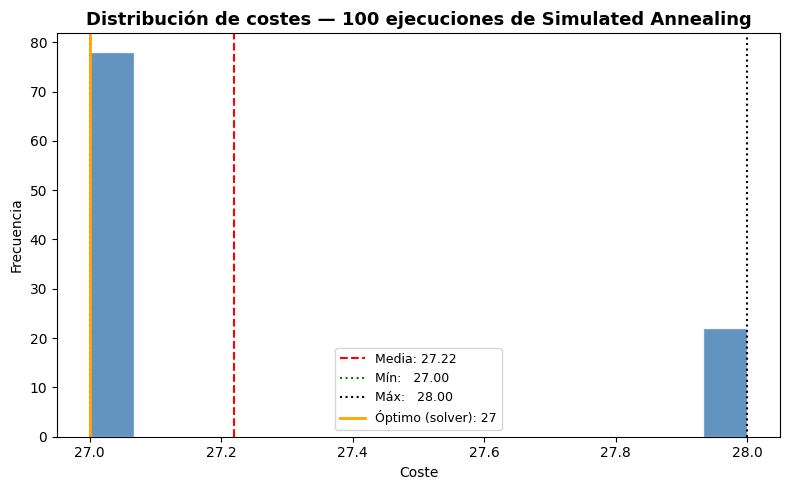

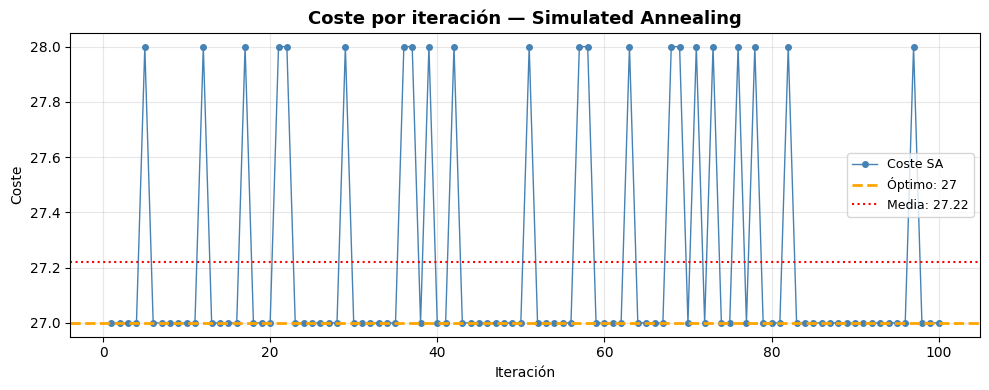

In [14]:
import matplotlib.pyplot as plt
# ---------------------------------------------
#                 HISTOGRAMA
# ---------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(resultados_sa, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(resultados_sa), color='red',    linestyle='--', linewidth=1.5, label=f'Media: {np.mean(resultados_sa):.2f}')
ax.axvline(np.min(resultados_sa),  color='green',  linestyle=':',  linewidth=1.5, label=f'Mín:   {np.min(resultados_sa):.2f}')
ax.axvline(np.max(resultados_sa),  color='black',  linestyle=':',  linewidth=1.5, label=f'Máx:   {np.max(resultados_sa):.2f}')
ax.axvline(OPTIMO,                 color='orange', linestyle='-',  linewidth=2,   label=f'Óptimo (solver): {OPTIMO}')

ax.set_title(f"Distribución de costes — {N_ITERACIONES} ejecuciones de Simulated Annealing", fontsize=13, fontweight='bold')
ax.set_xlabel("Coste")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ---------------------------------------------
#        EVOLUCIÓN POR ITERACIÓN
# ---------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(1, N_ITERACIONES+1), resultados_sa, marker='o', markersize=4,
        color='steelblue', linewidth=1, label='Coste SA')
ax.axhline(OPTIMO,                   color='orange', linestyle='--', linewidth=2, label=f'Óptimo: {OPTIMO}')
ax.axhline(np.mean(resultados_sa),   color='red',    linestyle=':',  linewidth=1.5, label=f'Media: {np.mean(resultados_sa):.2f}')

ax.set_title("Coste por iteración — Simulated Annealing", fontsize=13, fontweight='bold')
ax.set_xlabel("Iteración")
ax.set_ylabel("Coste")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

Respuesta

In [ ]:
def generar_matriz_aleatoria(num_tomas, num_actores):
    """
    Genera una matriz binaria num_tomas x num_actores
    - Solo 0 y 1
    - Ninguna fila puede ser toda 0
    """
    matriz = np.zeros((num_tomas, num_actores), dtype=int)

    for i in range(num_tomas):
        # Generar fila aleatoria
        fila = np.random.randint(0, 2, size=num_actores)
        # Asegurar que no sea todo 0
        if np.all(fila == 0):
            fila[np.random.randint(0, num_actores)] = 1
        matriz[i] = fila

    return matriz

In [ ]:
# Generar matriz con número de tomas entre 5 y 50 y actores entre 2 y 25
num_tomas = np.random.randint(5, 51)      # 5 a 50
num_actores = np.random.randint(2, 26)    # 2 a 25

matriz_tomas = generar_matriz_aleatoria(num_tomas, num_actores)
print("Tomas:", num_tomas, "Actores:", num_actores)
print(matriz_tomas)


Tomas: 44 Actores: 13
[[0 0 0 1 1 0 0 0 1 1 0 1 1]
 [0 0 0 1 1 1 1 1 1 1 0 0 1]
 [1 1 0 0 1 0 0 0 0 1 0 0 1]
 [1 0 1 0 1 1 0 1 0 1 0 1 1]
 [1 0 1 0 0 1 1 0 1 1 1 0 0]
 [0 1 1 0 1 1 0 0 0 1 1 0 0]
 [1 0 0 0 0 1 1 0 1 0 1 1 1]
 [1 1 0 1 1 1 0 0 0 0 0 0 1]
 [0 0 1 1 0 1 1 0 0 0 1 0 1]
 [1 1 1 1 1 1 1 1 1 0 1 0 1]
 [1 0 0 0 0 1 1 1 0 1 1 1 0]
 [1 1 1 1 0 0 1 1 1 0 1 0 0]
 [0 0 0 0 1 0 0 0 0 1 1 1 1]
 [1 1 0 1 1 0 0 0 1 0 1 0 0]
 [0 1 1 0 1 0 1 1 0 0 0 1 0]
 [0 0 0 0 0 0 1 1 1 1 1 0 0]
 [1 0 0 0 0 1 0 0 1 0 0 0 1]
 [1 1 1 1 1 0 0 0 1 0 1 1 0]
 [0 0 1 1 1 0 1 1 1 0 1 0 0]
 [0 0 0 0 1 1 1 1 1 1 0 1 0]
 [0 1 0 1 1 0 1 1 1 1 1 0 0]
 [0 0 1 0 1 1 1 0 1 1 1 1 0]
 [1 1 0 0 0 1 0 0 0 0 0 0 1]
 [0 0 0 1 0 1 0 1 0 0 0 0 1]
 [1 0 0 1 0 0 0 1 1 1 1 1 0]
 [1 0 0 1 0 0 0 0 1 0 0 0 1]
 [1 0 0 1 1 0 0 1 1 1 0 0 0]
 [0 1 1 0 1 0 0 0 1 1 1 0 0]
 [1 1 1 1 0 0 0 0 1 1 1 0 1]
 [1 1 1 0 1 0 0 1 1 1 0 1 0]
 [1 0 1 0 1 1 0 1 0 0 1 0 0]
 [0 1 1 1 0 0 0 1 0 0 1 1 1]
 [1 1 0 0 1 0 0 1 0 1 0 1 1]
 [1 1 0 0 0 0 0 1 1 1

**Aplica el algoritmo al juego de datos generado**

In [ ]:
# Aplicamos el algoritmo de Simulated Annealing para la matriz aleatoria anterior
sol = simulated_annealing(matriz_tomas, 100)
mostrar_solucion(sol, matriz_tomas)

       PLANIFICACIÓN DEL RODAJE

 DÍA 1
    Tomas     : Toma 1, Toma 3, Toma 27, Toma 33, Toma 37, Toma 42
    Actores   : Actor 1, Actor 2, Actor 4, Actor 5, Actor 7, Actor 8, Actor 9, Actor 10, Actor 12, Actor 13
    Coste día : 10 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 10 actor(es)-día


 DÍA 2
    Tomas     : Toma 5, Toma 9, Toma 16, Toma 17, Toma 24, Toma 26
    Actores   : Actor 1, Actor 3, Actor 4, Actor 6, Actor 7, Actor 8, Actor 9, Actor 10, Actor 11, Actor 13
    Coste día : 10 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 20 actor(es)-día


 DÍA 3
    Tomas     : Toma 7, Toma 8, Toma 10, Toma 15, Toma 38, Toma 41
    Actores   : Actor 1, Actor 2, Actor 3, Actor 4, Actor 5, Actor 6, Actor 7, Actor 8, Actor 9, Actor 11, Actor 12, Actor 13
    Coste día : 12 actor(es)
------------------------------------------------------------

 COSTE TOTAL: 32 actor(es)-día


 DÍA 4
    Tomas     : Toma 2, 

**Enumera las referencias que has utilizado (si ha sido necesario) para llevar a cabo el trabajo**

**Referencias**

- Jose Manuel Camacho Camacho. (2025/26). *Prácticas guiadas de Algoritmos de Optimización*.
    Universidad Internacional de Valencia (VIU).

- Raúl Reyero Díez. (2025/26). *Manual de Algoritmos de Optimización*.
    Universidad Internacional de Valencia (VIU).

- Anthropic. (2026). *Claude* (claude-sonnet-4-20250514) [Modelo de lenguaje de gran escala].
    https://www.anthropic.com

- OpenAI. (2026). *ChatGPT* (GPT-4) [Modelo de lenguaje de gran escala].
    https://www.openai.com


**Declaración de Uso de Inteligencia Artificial**

Para la realización de este trabajo se ha utilizado Claude y ChatGPT como
herramienta de asistencia en las siguientes tareas:

- **Depuración de código:** identificación y corrección de errores en la implementación de los algoritmos.
- **Consulta de sintaxis:** resolución de dudas puntuales sobre NumPy,
  itertools y otras librerías de Python.
- **Refinamiento de redacción:** mejora de la claridad en los textos
  explicativos y justificaciones matemáticas.

*Nota: Todo el código y los textos generados han sido revisados, ejecutados
y validados por las autoras para garantizar su veracidad y coherencia con
los contenidos de la asignatura.*

**Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño.**

**Líneas de Trabajo Futuro**

***Mejoras sobre los métodos actuales:***
- Mejorar la función de cota inferior (CI) en el método de Branch and Bound para que sea más ajustada y realice una poda más agresiva, reduciendo así el espacio de búsqueda.
- Explorar otros algoritmos metaheurísticos, como los Algoritmos Genéticos o la Colonia de Hormias, que podrían encontrar mejores soluciones en menos tiempo para datos más grandes.
- Aplicar conocimientos de la asignatura *Aprendizaje Supervisado* para ajustar los hiperparámetros del *Simulated Annealing* mediente técnicas como *grid search*.

**Variaciones del Problema:**
- **Turnos de Grabación:** introducir varios turnos por día (mañana/tarde), lo que añadiría una nueva dimensión al problema y aumentaría el espacio de búsqueda.
- **Costes variables por actor:** que cada actor tenga un cahé diferente.
- **Costes variables por volumen:** que el coste de un actor no sea proporcional al número de tomas grabadas en un día, sino que siga una tarifa escalonada. Por ejempli si graba una toma cobra el 100%, pero si graba dos el coste total es el 190% (no el 200%), reflejando descuentos por volumen.
- **Restricciones de descanso:** que un actor no pueda trabajar más de $x$ días consecutivos, añadiendo restricciones temporales al modelo.

